In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

np.random.seed(42)


In [3]:
# -----------------------------
# 1) Data
# -----------------------------
def load_data(n_samples=500, noise=0.2, test_size=0.2, random_state=42, show_plot=True):
    """ Generate moon dataset and optionally show dataset visualization in notebook."""
    X, y = make_moons(n_samples=n_samples, noise=noise, random_state=random_state)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    if show_plot:
        plt.figure(figsize=(10, 4))

        plt.subplot(1, 2, 1)
        plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, cmap="viridis", edgecolors="k")
        plt.title("Training Data")
        plt.xlabel("x1")
        plt.ylabel("x2")

        plt.subplot(1, 2, 2)
        plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap="viridis", edgecolors="k")
        plt.title("Test Data")
        plt.xlabel("x1")
        plt.ylabel("x2")

        plt.tight_layout()
        plt.show()

    # Return shapes compatible with your NN (n_x, m)
    return X_train.T, y_train.reshape(1, -1), X_test.T, y_test.reshape(1, -1)


In [26]:
# -----------------------------
# 2) Activations
# -----------------------------
def sigmoid(z):
    """Layer 2 activation (Output Layer): sigmoid"""
    return 1 / (1 + np.exp(-z))

In [27]:
# -----------------------------
# 3) Init params
# -----------------------------
def initialize_parameters(n_x, n_h, n_y, seed=42):
    """
    Architecture:
      Layer 0: X  ∈ R^{n_x×m}
      Layer 1: tanh hidden layer with n_h units
      Layer 2: sigmoid output layer with n_y units (binary => n_y=1)

    Parameters:
      W1 ∈ R^{n_h×n_x}, b1 ∈ R^{n_h×1}
      W2 ∈ R^{n_y×n_h}, b2 ∈ R^{n_y×1}
    """
    np.random.seed(seed)
    W1 = np.random.randn(n_h, n_x) * 0.01
    b1 = np.zeros((n_h, 1))
    W2 = np.random.randn(n_y, n_h) * 0.01
    b2 = np.zeros((n_y, 1))
    return {"W1": W1, "b1": b1, "W2": W2, "b2": b2}


In [28]:
# -----------------------------
# 4) Forward
# -----------------------------
def forward_propagation(X, parameters):
    """
    Architecture (Forward):
      Layer 0 (Input):
        X ∈ R^{n_x×m}

      Layer 1 (Hidden, tanh):
        Z1 = W1·X + b1
        A1 = tanh(Z1)

      Layer 2 (Output, sigmoid):
        Z2 = W2·A1 + b2
        A2 = sigmoid(Z2) = ŷ
    """
    W1, b1, W2, b2 = parameters["W1"], parameters["b1"], parameters["W2"], parameters["b2"]

    # ---- Layer 1 (Hidden Layer) ----
    Z1 = np.dot(W1, X) + b1
    A1 = np.tanh(Z1)

    # ---- Layer 2 (Output Layer) ----
    Z2 = np.dot(W2, A1) + b2
    A2 = sigmoid(Z2)

    cache = {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2}
    return A2, cache

In [32]:
# -----------------------------
# 5) Cost
# -----------------------------
def compute_cost(A2, Y, eps=1e-12):
    """
    Loss (Binary Cross-Entropy):
      J = -1/m Σ [ y log(ŷ) + (1-y) log(1-ŷ) ]
    """
    m = Y.shape[1]
    A2 = np.clip(A2, eps, 1 - eps)  # avoid log(0)
    logprobs = np.multiply(np.log(A2), Y) + np.multiply(np.log(1 - A2), 1 - Y)
    cost = -np.sum(logprobs) / m
    return float(np.squeeze(cost))

In [31]:
# -----------------------------
# 6) Backward
# -----------------------------
def backward_propagation(parameters, cache, X, Y):
    """
    Architecture (Backward):
      Layer 2:
        dZ2 = A2 - Y
        dW2 = 1/m · dZ2·A1^T
        db2 = 1/m · sum(dZ2)

      Layer 1:
        dZ1 = (W2^T·dZ2) ⊙ (1 - A1^2)    (tanh derivative)
        dW1 = 1/m · dZ1·X^T
        db1 = 1/m · sum(dZ1)
    """
    m = X.shape[1]
    W2 = parameters["W2"]
    A1, A2 = cache["A1"], cache["A2"]

    # ---- Layer 2 gradients (Output Layer) ----
    dZ2 = A2 - Y
    dW2 = np.dot(dZ2, A1.T) / m
    db2 = np.sum(dZ2, axis=1, keepdims=True) / m

    # ---- Layer 1 gradients (Hidden Layer) ----
    dZ1 = np.dot(W2.T, dZ2) * (1 - np.power(A1, 2))
    dW1 = np.dot(dZ1, X.T) / m
    db1 = np.sum(dZ1, axis=1, keepdims=True) / m

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

In [33]:
# -----------------------------
# 7) Update
# -----------------------------
def update_parameters(parameters, grads, learning_rate=0.01):
    """
    Gradient Descent update:
      W := W - α dW
      b := b - α db
    """
    parameters["W1"] -= learning_rate * grads["dW1"]
    parameters["b1"] -= learning_rate * grads["db1"]
    parameters["W2"] -= learning_rate * grads["dW2"]
    parameters["b2"] -= learning_rate * grads["db2"]
    return parameters

In [34]:
# -----------------------------
# 8) Train
# -----------------------------
def train_model(X, Y, n_h=5, num_iterations=2000, learning_rate=0.5, print_every=200):
    """
    Full training loop:
      Forward -> Cost -> Backward -> Update
    """
    n_x = X.shape[0]
    n_y = Y.shape[0]
    parameters = initialize_parameters(n_x, n_h, n_y)

    costs = []
    for i in range(num_iterations):
        # Forward
        A2, cache = forward_propagation(X, parameters)

        # Cost
        cost = compute_cost(A2, Y)

        # Backward
        grads = backward_propagation(parameters, cache, X, Y)

        # Update
        parameters = update_parameters(parameters, grads, learning_rate)

        # record
        if i % 100 == 0:
            costs.append(cost)

        if print_every and i % print_every == 0:
            print(f"Iteration {i:5d} | Cost = {cost:.6f}")

    return parameters, costs

In [35]:
# -----------------------------
# 9) Predict
# -----------------------------
def predict(parameters, X):
    """
    Predict:
      ŷ = sigmoid(...) > 0.5 => 1 else 0
    """
    A2, _ = forward_propagation(X, parameters)
    return (A2 > 0.5).astype(int)

def predict_proba(parameters, X):
    """Return probability ŷ"""
    A2, _ = forward_propagation(X, parameters)
    return A2

In [12]:
# -----------------------------
# 10) Plot helpers (Jupyter inline)
# -----------------------------
def plot_loss(costs):
    plt.figure(figsize=(7, 4))
    plt.plot(costs, marker="o", markersize=3, linewidth=1)
    plt.title("Training Loss")
    plt.xlabel("Checkpoints (every 100 iterations)")
    plt.ylabel("Cost")
    plt.grid(True, alpha=0.3)
    plt.show()


In [36]:
def plot_decision_boundary(parameters, X, Y, title="Decision Boundary", step=0.01):
    """
    Visualize decision boundary for a 2D input (Layer 0 has 2 features).
      X ∈ R^{2×m}, Y ∈ R^{1×m}
    """
    X_ = X.T
    y_ = Y.flatten()

    x_min, x_max = X_[:, 0].min() - 0.5, X_[:, 0].max() + 0.5
    y_min, y_max = X_[:, 1].min() - 0.5, X_[:, 1].max() + 0.5

    xx, yy = np.meshgrid(np.arange(x_min, x_max, step),
                         np.arange(y_min, y_max, step))
    grid = np.c_[xx.ravel(), yy.ravel()].T  # (2, N)

    Z = predict(parameters, grid).reshape(xx.shape)

    plt.figure(figsize=(7, 5))
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.6)
    plt.scatter(X_[:, 0], X_[:, 1], c=y_, cmap=plt.cm.RdYlBu, edgecolors="k")
    plt.title(title)
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

In [48]:
# -------------------------------------------这是一条分割线------------------------------------------

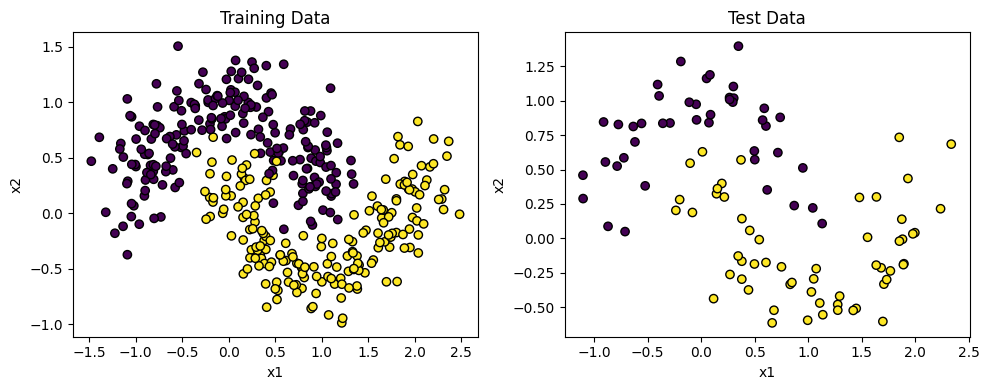

In [37]:
# 1) Load and visualize dataset (shows picture #1)
X_train, Y_train, X_test, Y_test = load_data(show_plot=True)

In [38]:
print("Train:", X_train.shape, Y_train.shape)
print("Test :", X_test.shape, Y_test.shape)

Train: (2, 400) (1, 400)
Test : (2, 100) (1, 100)


In [39]:
# 2) Train model (prints cost during training)
parameters, costs = train_model(
    X_train, Y_train,
    n_h=5,
    num_iterations=2000,     # demo-friendly; increase to 10000 if you want
    learning_rate=0.5,
    print_every=200
)

Iteration     0 | Cost = 0.693153
Iteration   200 | Cost = 0.285995
Iteration   400 | Cost = 0.284047
Iteration   600 | Cost = 0.282923
Iteration   800 | Cost = 0.282075
Iteration  1000 | Cost = 0.281208
Iteration  1200 | Cost = 0.280043
Iteration  1400 | Cost = 0.278127
Iteration  1600 | Cost = 0.271952
Iteration  1800 | Cost = 0.145925


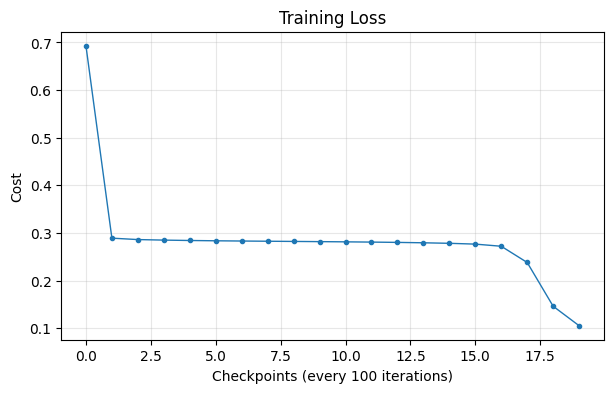

In [40]:
# 3) Plot loss curve (shows picture #2)
plot_loss(costs)

In [41]:
# 4) Evaluate accuracy
train_pred = predict(parameters, X_train)
test_pred  = predict(parameters, X_test)

In [42]:
train_acc = np.mean(train_pred == Y_train) * 100
test_acc  = np.mean(test_pred == Y_test) * 100

In [43]:
print(f"Train Accuracy: {train_acc:.2f}%")
print(f"Test  Accuracy: {test_acc:.2f}%")

Train Accuracy: 98.00%
Test  Accuracy: 98.00%


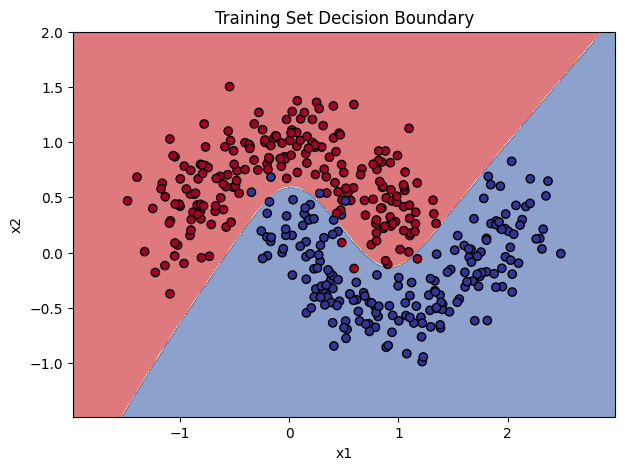

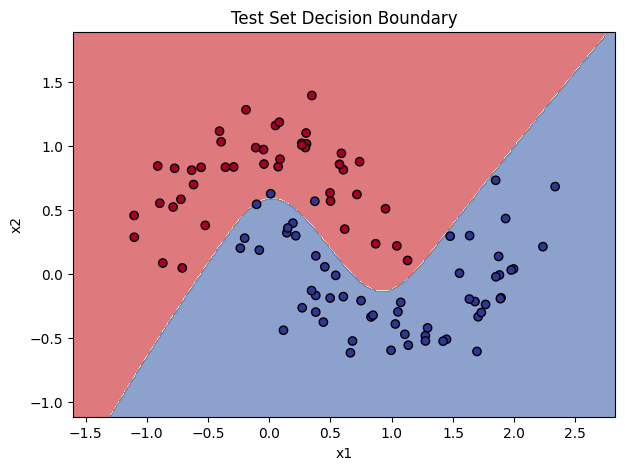

In [44]:
# 5) Plot decision boundaries (shows picture #3 and #4)
plot_decision_boundary(parameters, X_train, Y_train, title="Training Set Decision Boundary")
plot_decision_boundary(parameters, X_test, Y_test, title="Test Set Decision Boundary")

In [45]:
# 6) Example prediction
sample_idx = 0
sample_x = X_test[:, sample_idx:sample_idx+1]
sample_y = Y_test[:, sample_idx:sample_idx+1]

In [46]:
prob = predict_proba(parameters, sample_x)
pred = predict(parameters, sample_x)

In [47]:
print("\n[Example Prediction]")
print(f"Input: [{sample_x[0,0]:.3f}, {sample_x[1,0]:.3f}]")
print(f"True label: {sample_y[0,0]}")
print(f"Pred prob : {prob[0,0]:.4f}")
print(f"Pred label: {pred[0,0]}")


[Example Prediction]
Input: [0.380, 0.143]
True label: 1
Pred prob : 0.8252
Pred label: 1
